In [2]:
%load_ext autoreload    
%autoreload 2

In [3]:
import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import plots as plots

from spins_sdp import (
    ising_hamiltonian,
    magnetization_qutip,
    gibbs_state_from_spectrum,
    npa_level,
    moment_matrix_dict,
    build_sdp_variables,
    dict_to_cvxpy_matrix_from_expr,
    ising_energy_expr,
    average_magnetization,
    ising_pauli_symbolic_terms,
    build_diagonality_constraints,
    build_lambda_matrix
)

from tools import *

## 1. Exact Diagonalization

In [5]:
# Model parameters
N = 2
J = 1.0
h = 0
k = 0
boundary = "periodic"
beta = 1.0
axis = 'z'

# create hamiltonian
H = ising_hamiltonian(N, J, h, k)
eigenvalues, eigenstates = H.eigenstates()

# Ground state
E0 = eigenvalues[0]
psi0 = eigenstates[0]

## 2. SDP Relaxation (Ground State Energy)

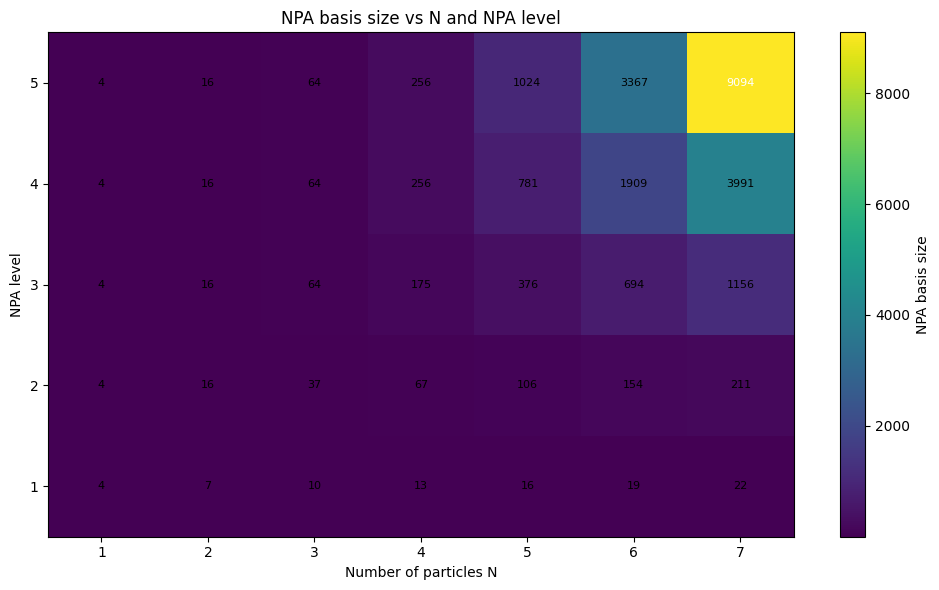

In [4]:
plots.npa_basis_size_heatmap(N=7, max_NPA_level=5)


In [ ]:
# SDP parameters
NPA_level = 2
N = 2
solver = "MOSEK" # Look into this later

exact_E = exact_ground_state_eigenpair(H)[0]

E_lb_val = npa_lb_energy(
    J=J, h=h, k=k,
    N=N,
    NPA_level=NPA_level,
    solver=solver,
    boundary=boundary
)

print(f"Computed E_lb/N from function: {E_lb_val/N}")
print(f"Exact E0/N: {exact_E/N}")


Ns, E_exact, E_lb = plots.plot_exact_vs_npa_energy_vs_N(
    N_values=range(2, 15),
    J=1.0, h=0.7, k=0.3,
    NPA_level=1,
    boundary="periodic",
    solver=solver,
    per_site=True
)   

#  Bug/Numerical error somewhere since the NPA lower bound is above the exact energy for some N.


Computed E_lb/N from function: -0.9999999999996102
Exact E0/N: -1.0


In [10]:
exact_data = benchmark_exact_diagonalization(
    N_values=range(2, 13),
    J=J, h=h, k=k,
    boundary="periodic",
    repeats=1,
)

In [14]:
npa_data_1 = benchmark_npa_relaxation(
    N_values=range(2, 25),
    NPA_level=1,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
    scs_eps=1e-6,
    scs_max_iters=20000,
)

In [12]:
npa_data_2 = benchmark_npa_relaxation(
    N_values=range(2, 8),
    NPA_level=2,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
    scs_eps=1e-6,
    scs_max_iters=20000,
)

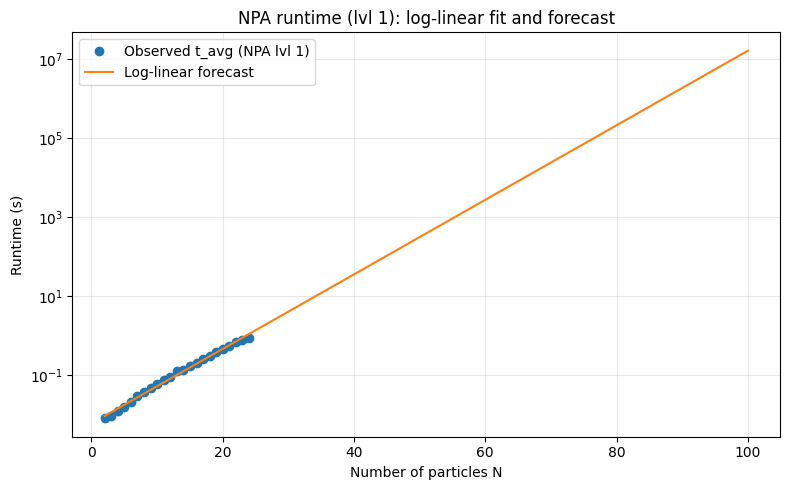

Fit: log t = 0.217311 * N + -5.12943
R^2 (log-scale): 0.99322
Forecast at N=100: 1.622e+07 s


In [ ]:
# Log-linear regression on NPA runtimes (t_avg) and forecast to N=100
import numpy as np
import matplotlib.pyplot as plt

N_obs = np.array(npa_data_1["N"], dtype=float)
t_obs = np.array(npa_data_1["t_avg"], dtype=float)

# guard against any zeros/negatives before taking log
mask = t_obs > 0
N_obs = N_obs[mask]
t_obs = t_obs[mask]

# log-linear fit: log t = a N + b
coef = np.polyfit(N_obs, np.log(t_obs), 1)
a, b = coef
predict = lambda N: np.exp(a * N + b)

# R^2 on log-scale
log_pred = a * N_obs + b
log_true = np.log(t_obs)
ss_res = np.sum((log_true - log_pred) ** 2)
ss_tot = np.sum((log_true - np.mean(log_true)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

# forecast up to N=100
N_fore = np.arange(int(N_obs.min()), 101, dtype=float)
t_fore = predict(N_fore)

plt.figure(figsize=(8, 5))
plt.plot(N_obs, t_obs, "o", label="Observed t_avg (NPA lvl 1)")
plt.plot(N_fore, t_fore, "-", label="Log-linear forecast")
plt.yscale("log")
plt.xlabel("Number of particles N")
plt.ylabel("Runtime (s)")
plt.title("NPA runtime (lvl 1): log-linear fit and forecast")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fit: log t = {a:.6g} * N + {b:.6g}")
print(f"R^2 (log-scale): {r2:.5f}")
print(f"Forecast at N=100: {predict(100):.3e} s")

print("Would take 115.74 days to run N=100")


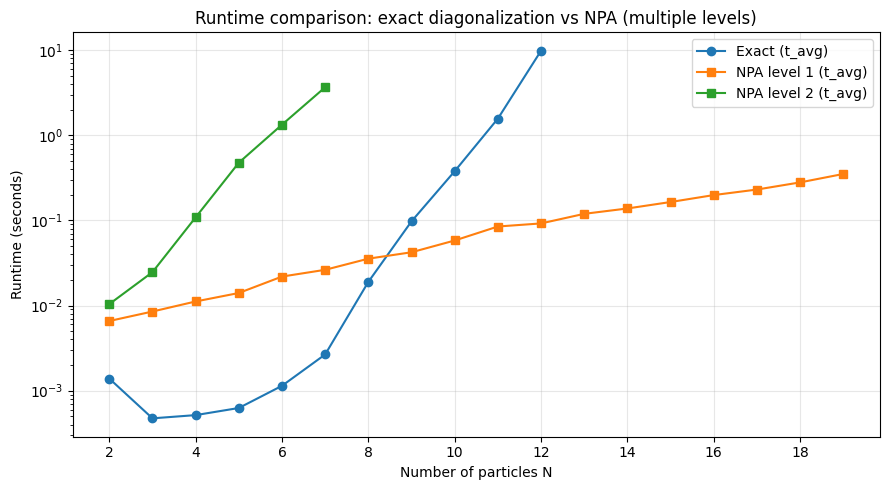

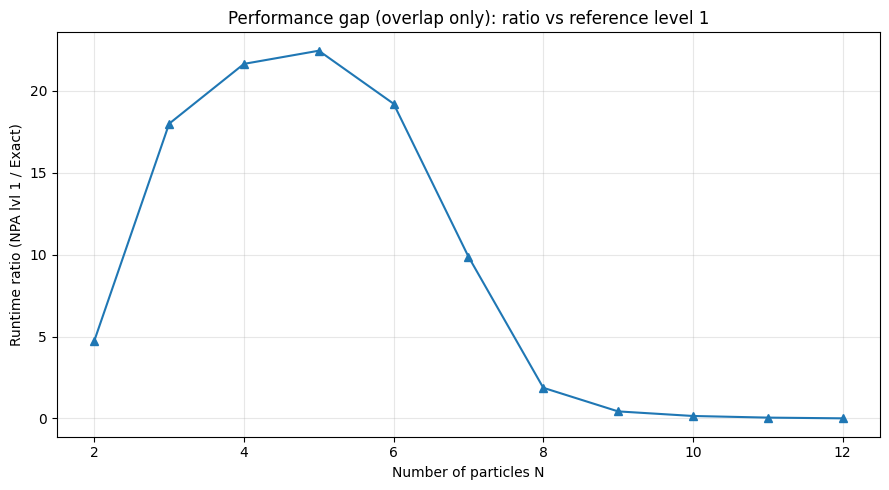

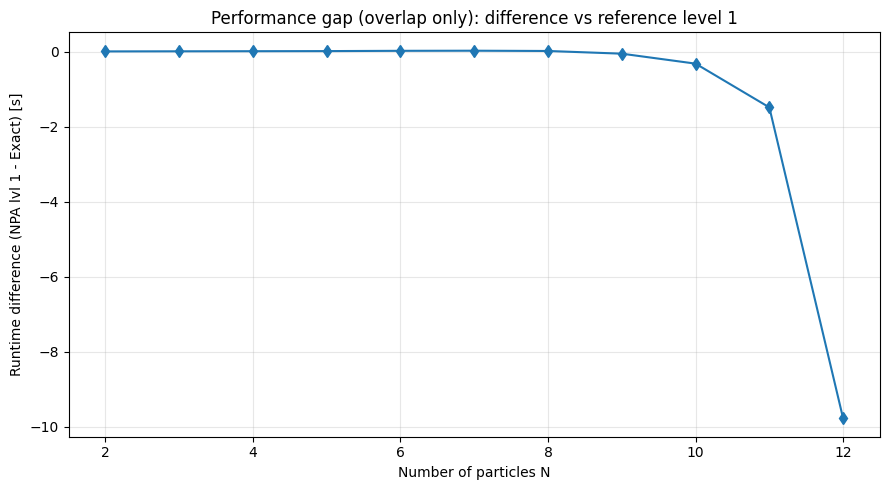

In [13]:
npa_data_by_level = {
    1: npa_data_1,
    2: npa_data_2
}

out = plots.plot_runtime_comparison_multi_levels(
    exact_data=exact_data,
    npa_data_by_level=npa_data_by_level,
    levels=[1,2],
    use="t_avg",
    logy=True,
)

In [14]:
np.__config__.show()

{
  "Compilers": {
    "c": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35222",
      "commands": "cl"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.2.4",
      "commands": "cython"
    },
    "c++": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35222",
      "commands": "cl"
    }
  },
  "Machine Information": {
    "host": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    },
    "build": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    }
  },
  "Build Dependencies": {
    "blas": {
      "name": "scipy-openblas",
      "found": true,
      "version": "0.3.30",
      "detection method": "pkgconfig",
      "include directory": "C:/Users/runneradmin/AppData/Local/Temp/cibw-run-xs9t8v6k/cp313-win_amd64/build/venv/Lib/site-packages/scipy_openblas64/include",
      "lib directo

c:\Users\lmatos\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\__config__.py:155: UserWarning: Install `pyyaml` for better output
  warnings.warn("Install `pyyaml` for better output", stacklevel=1)
